# **Exploring Police Data (with data quality issues) flagged as mental health instances**

## 1. Data Wrangling

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import folium

from vizdataquality import calculate as vdqc, datasets as vdqd, plot as vdqp

In [2]:
query = """
SELECT *
FROM `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.src_BD_IncidentData`
"""

In [3]:
query2 = """
SELECT *
FROM `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.src_BD_incidentdata_2020_04_to2022_03`
"""

In [4]:
client = bigquery.Client()

/opt/conda/lib/python3.10/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [5]:
dataset_1 = list(client.query(query).result())

In [6]:
dataset_2 = list(client.query(query2).result())

In [7]:
df_1 = pd.DataFrame([dict(row.items()) for row in dataset_1])

In [8]:
df_2 = pd.DataFrame([dict(row.items()) for row in dataset_2])
extra_cols = [col for col in df_2.columns if col not in df_1.columns]
df_2 = df_2.reindex(columns=df_1.columns.insert(len(df_1.columns),extra_cols))

## Data Cleaning

In [9]:
df_2.columns

Index(['lsoa_name1', 'Index', 'lsoa1', 'lsoa', 'incident_ref', 'reswodep',
       'initial_grade', 'attended', 'incident_sub_type', 'disposition_1_code',
       'qualifiers', 'final_grade', 'incident_end_date', 'cb_date_added',
       'incident_type', 'lsoa_name', 'incident_start_date', 'incident_id'],
      dtype='object')

In [10]:
df_2.rename(columns={'lsoa':'lsoa_messy','reswodep':'reswodep_messy','attended':'attended_messy','incident_sub_type':'incident_sub_type_messy','lsoa_name':'lsoa_name_messy'},inplace=True)

In [11]:
def extract_lsoa_name(cell):
    values = cell.split(',')
    lsoa_values = [value.strip() for value in values if value.strip().startswith('Br')]
    return lsoa_values[0] if lsoa_values else "Unknown"

df_2['lsoa_name'] = df_2['lsoa_name_messy'].apply(extract_lsoa_name)

In [12]:
def extract_lsoa_code(cell):
    values = cell.split(',')
    lsoa_code_values = [value.strip() for value in values if value.strip().startswith('E')]
    return lsoa_code_values[0] if lsoa_code_values else "Unknown"

In [13]:
df_2['lsoa'] = np.where(~df_2['lsoa_messy'].str.contains(r'\bE\w*'),df_2['lsoa_name_messy'].apply(extract_lsoa_code),df_2['lsoa_messy'])

In [14]:
df_2['reswodep'] = np.where(df_2['reswodep_messy'].isin(['Y','N']),df_2['reswodep_messy'],"NV")

In [15]:
condition = df_2['reswodep'].str.contains('NV') & (df_2['lsoa_messy'].str.startswith('Y')|df_2['lsoa_messy'].str.startswith('N'))
df_2['reswodep'] = np.where(condition,df_2['lsoa_messy'],df_2['reswodep'])

In [16]:
def extract_reswodep_code(cell):
    values = cell.split(',')
    if len(values)==5:
        reswodep_code_values = values[0].strip()
    else:
        reswodep_code_values = "NV"
    return reswodep_code_values if reswodep_code_values else "NV"

In [17]:
df_2['reswodep'] = np.where(df_2['reswodep']=='NV',df_2['lsoa_name_messy'].apply(extract_reswodep_code),df_2['reswodep'])

In [18]:
def extract_attended_code(cell):
    values = cell.split(',')
    if len(values)==4:
        attended_code_values = values[0].strip()
    elif len(values)==5:
        attended_code_values = values[1].strip()
    else:
        attended_code_values = "NV"
    return attended_code_values if attended_code_values else "NV"

In [19]:
df_2['attended'] = np.where(~df_2['attended_messy'].isin(['Y','N']),
                            df_2['lsoa_name_messy'].apply(extract_attended_code),df_2['attended_messy'])

In [20]:
df_2['incident_sub_type_1'] = np.where(df_2['attended_messy'].isin(['Y','N']),'',df_2['attended_messy'])
df_2['incident_sub_type_2'] = np.where(df_2['reswodep_messy'].isin(['Y','N']),'',df_2['reswodep_messy'])

In [21]:
df_2['incident_sub_type_1'] = df_2['incident_sub_type_1'].str.rstrip('"')
df_2['incident_sub_type_2'] = df_2['incident_sub_type_2'].str.rstrip('"')

In [22]:
df_2['incident_sub_type'] = df_2[['incident_sub_type_messy', 'incident_sub_type_2', 'incident_sub_type_1']].fillna('').apply(lambda row: '-'.join(
                                        [val for val in row if val.strip() != '']), axis=1)

In [23]:
df_2_cleaned = df_2.drop(['lsoa_messy','reswodep_messy','attended_messy','incident_sub_type_messy','lsoa_name_messy','incident_sub_type_1','incident_sub_type_2'],axis=1)

In [24]:
df_2_cleaned.to_csv('bd_2020_2022.csv')

In [25]:
df_import = pd.read_csv('bd_2020_2022.csv')
df_import = df_import.drop(df_import.columns[0],axis=1)

In [26]:
df_output = vdqc.calc(df_import)
df_output

,Data type,Example value,Number of values,Number of zero values,Number of missing values,Number of unique values,Value lengths,Character patterns,Numeric percentiles,Datetime percentiles,Uniqueness,Data type conflict
_column,,,,,,,,,,,,
lsoa_name1,float64,,0,0,11158,0,,,"nan,nan,nan,nan,nan",,All missing,OK
Index,float64,,0,0,11158,0,,,"nan,nan,nan,nan,nan",,All missing,OK
lsoa1,float64,,0,0,11158,0,,,"nan,nan,nan,nan,nan",,All missing,OK
incident_ref,float64,,0,0,11158,0,,,"nan,nan,nan,nan,nan",,All missing,OK
initial_grade,object,PRIORITY,2426,0,8732,6,"8,16",a(),,,Other,OK
disposition_1_code,float64,,0,0,11158,0,,,"nan,nan,nan,nan,nan",,All missing,OK
qualifiers,object,MENTAL HEALTH INVOL,11158,0,0,2,"19,20","a""",,,Binary,OK
final_grade,object,STANDARD,11158,0,0,6,"8,16",a(),,,Other,OK
incident_end_date,object,2021-12-26 12:01:00+00:00,11158,0,0,11071,"25,25",0-:+,,,Other,OK


In [27]:
complete_df = pd.concat([df_1,df_2_cleaned], ignore_index=True, sort=False)
complete_df.head()

,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,qualifiers,final_grade,incident_end_date,cb_date_added,incident_type,lsoa_name,incident_start_date,incident_id
0,Bradford 002G,None,E01010698,E01010698,WYP-20190307-0933,True,None,False,NICHE CREATE OCCURRENCE,461.0,MENTAL HEALTH INVOL,FCMU ONLY,2019-03-07 17:52:30+00:00,2023-03-14 00:00:00+00:00,THEFT - SHOPLIFTING,Bradford 002G,2019-03-07 14:38:10+00:00,NaN
1,Bradford 003B,None,E01010768,E01010768,WYP-20190415-0307,True,None,False,NO OCCURRENCE REQUIRED,498.0,MENTAL HEALTH INVOL,FCMU ONLY,2019-04-15 09:54:07+00:00,2023-03-14 00:00:00+00:00,NO CRIME RECORDED (EG VICTIM NOT LOCATED),Bradford 003B,2019-04-15 08:34:09+00:00,NaN
2,Bradford 004E,None,E01010642,E01010642,WYP-20180902-1163,True,None,False,NICHE CREATE OCCURRENCE,480.0,MENTAL HEALTH INVOL,FCMU ONLY,2018-09-02 15:01:28+00:00,2023-03-14 00:00:00+00:00,CRIMINAL DAMAGE,Bradford 004E,2018-09-02 14:11:11+00:00,NaN
3,Bradford 004H,None,E01010645,E01010645,WYP-20190902-1159,True,None,False,NICHE CREATE OCCURRENCE,460.0,MENTAL HEALTH INVOL,FCMU ONLY,2019-09-02 17:53:30+00:00,2023-03-14 00:00:00+00:00,THEFT - OTHER / HANDLING,Bradford 004H,2019-09-02 16:23:20+00:00,NaN
4,Bradford 008G,None,E01010710,E01010710,WYP-20190515-1025,True,None,False,NICHE CREATE OCCURRENCE,461.0,MENTAL HEALTH INVOL,FCMU ONLY,2019-05-15 16:51:01+00:00,2023-03-14 00:00:00+00:00,THEFT - SHOPLIFTING,Bradford 008G,2019-05-15 14:46:17+00:00,NaN


In [28]:
complete_df.tail()

,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,qualifiers,final_grade,incident_end_date,cb_date_added,incident_type,lsoa_name,incident_start_date,incident_id
26752,NaN,NaN,NaN,E01010624,NaN,N,PRIORITY,Y,ASS OTHER PUBLIC AGY- NO APP HO QUALIFIER,NaN,"""MENTAL HEALTH INVOL",STANDARD,2021-11-18 13:32:00+00:00,2023-03-14 00:00:00+00:00,CONCERN FOR SAFETY,Bradford 042E,2021-11-18 13:01:00+00:00,274236.0
26753,NaN,NaN,NaN,E01010734,NaN,N,PRIORITY,Y,ASS OTHER PUBLIC AGY- NO APP HO QUALIFIER,NaN,"""MENTAL HEALTH INVOL",STANDARD,2020-08-19 23:41:00+00:00,2023-03-14 00:00:00+00:00,CONCERN FOR SAFETY,Bradford 045D,2020-08-19 22:10:00+00:00,70543.0
26754,NaN,NaN,NaN,E01010733,NaN,N,,Y,DEMENTIA- ASS OTHER PUBLIC AGY,NaN,"""MENTAL HEALTH INVOL",STANDARD,2020-11-14 16:35:00+00:00,2023-03-14 00:00:00+00:00,CONCERN FOR SAFETY,Bradford 048C,2020-11-14 16:26:00+00:00,111118.0
26755,NaN,NaN,NaN,E01010738,NaN,N,PRIORITY,Y,ASS OTHER PUBLIC AGY- NO APP HO QUALIFIER,NaN,"""MENTAL HEALTH INVOL",STANDARD,2021-05-24 17:42:00+00:00,2023-03-14 00:00:00+00:00,CONCERN FOR SAFETY,Bradford 051B,2021-05-24 17:09:00+00:00,195572.0
26756,NaN,NaN,NaN,Unknown,NaN,N,EMERGENCY,Y,OTH AGY/FORCE DEAL- ASS OTHER PUBLIC AGY,NaN,"""MENTAL HEALTH INVOL",STANDARD,2020-04-27 13:16:00+00:00,2023-03-14 00:00:00+00:00,COLLAPSE/ILLNESS/INJURY/TRAPPE,Unknown,2020-04-27 12:44:00+00:00,14587.0


## Wrangling and Exploratory Data Analysis

In [29]:
def wrangle_date_col(dataframe, date_col):
    dataframe[date_col] = pd.to_datetime(dataframe[date_col])
    nw_col_name = "_".join(date_col.split('_')[:2])
    dataframe[nw_col_name+"_"+str("year")] = dataframe[date_col].dt.year
    dataframe[nw_col_name+"_"+str("month")] = dataframe[date_col].dt.month_name()
    dataframe[nw_col_name+"_"+str("day_num")] = dataframe[date_col].dt.day
    dataframe[nw_col_name+"_"+str("day")] = dataframe[date_col].dt.day_name()
    dataframe[nw_col_name+"_"+str("hour")] = dataframe[date_col].dt.hour
    
    return dataframe

In [30]:
def generate_colors(num_colors):
    colors = []
    for i in range(num_colors):
        colors.append("#{:06x}".format(np.random.randint(0, 0xFFFFFF)))
    return colors

In [31]:
df = wrangle_date_col(complete_df,'incident_start_date')
df = wrangle_date_col(complete_df,'incident_end_date')

In [32]:
sns.set(rc={'figure.figsize':(11, 4)})

In [33]:
font_properties = {'family': 'sans-serif','weight': 'bold','size': 12}
tickfont_properties = {'family': 'sans-serif','size': 9}

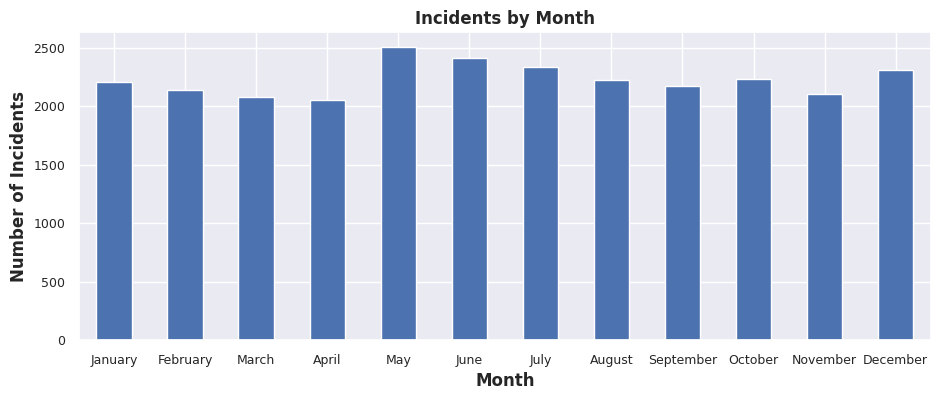

In [34]:
# Plotting time
def plot_by_time(df, date_col,date_component):
    desired_col_name = "_".join([date_col,date_component])
    if date_component == "month":
        date_list = pd.date_range(start='2017-01-01', periods=12, freq='MS').strftime('%B').tolist()
    elif date_component == "day":
        date_list = pd.date_range(start='2017-01-01', periods=7, freq='D').strftime('%A').tolist()
    df[desired_col_name] = pd.Categorical(df[desired_col_name], categories=date_list, ordered=True)
    df.groupby(f"{desired_col_name}").size().plot(kind='bar', title=f"Incidents by {date_component.capitalize()}")
    if date_component == "month":
        plt.xticks(ticks=range(0, 12), rotation=0, labels=date_list,**tickfont_properties)
    elif date_component == "day":
        plt.xticks(ticks=range(0, 7), rotation=0, labels=date_list,**tickfont_properties)
    plt.yticks(**tickfont_properties)
    plt.xlabel(f'{date_component.capitalize()}',**font_properties)
    plt.ylabel('Number of Incidents',**font_properties)
    plt.title(f"Incidents by {date_component.capitalize()}",**font_properties)
    plt.show()

plot_by_time(df,"incident_start","month")

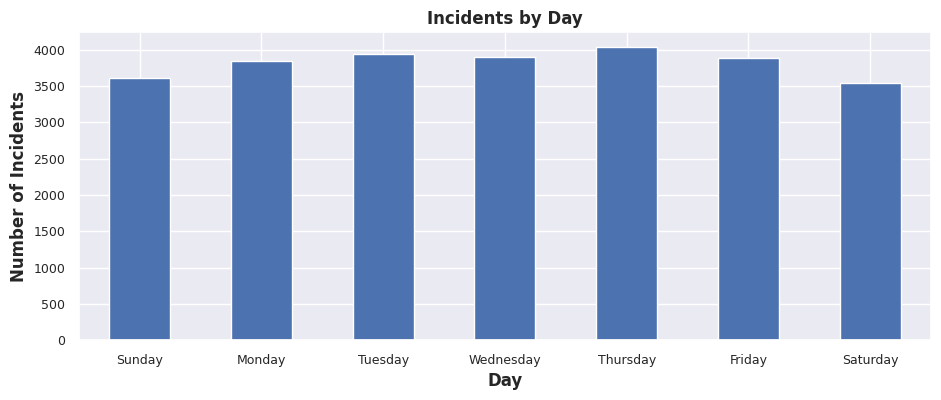

In [35]:
plot_by_time(df,"incident_start","day")

Text(0, 0.5, 'Counts related to\n mental health')

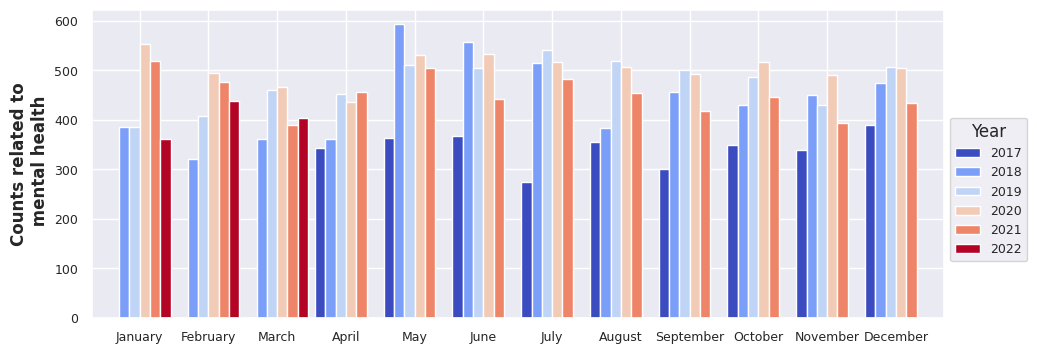

In [36]:
grouped_df = df.groupby(['incident_start_month', 'incident_start_year']).size().unstack()
ax = grouped_df.plot(kind='bar', width=0.9, colormap='coolwarm')

ax.set_xticklabels(grouped_df.index, rotation=0, ha='center')

ax.legend(title='Year', bbox_to_anchor=(1, 0.67),prop=tickfont_properties)
plt.xlabel('',**font_properties)
plt.xticks(**tickfont_properties)
plt.yticks(**tickfont_properties)
plt.ylabel('Counts related to\n mental health',**font_properties)

/var/tmp/ipykernel_9560/1785803115.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  daily_counts = df.groupby(df['incident_start_date'].dt.to_period('D')).size()


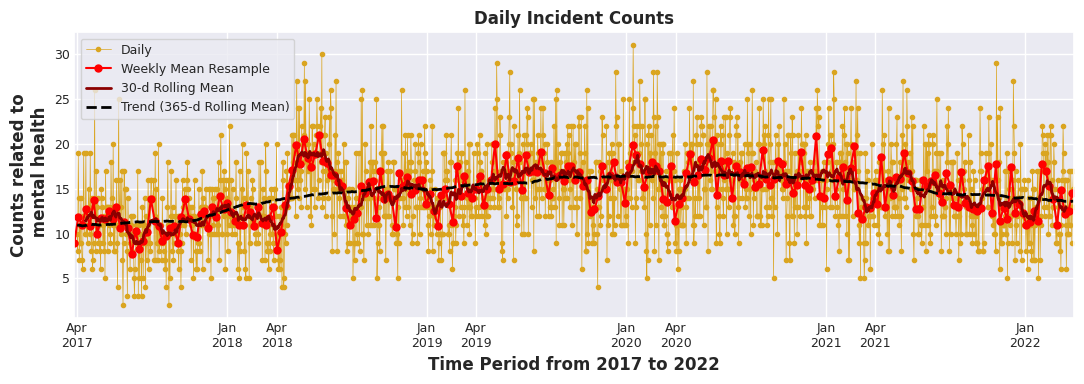

In [37]:
daily_counts = df.groupby(df['incident_start_date'].dt.to_period('D')).size()
weekly_mean = daily_counts.resample('W').mean()
rolling_30d = daily_counts.rolling(30,center=True).mean()
trend = daily_counts.rolling(365,center=True,min_periods=70).mean()

fig, ax = plt.subplots()
daily_counts.plot(ax=ax,marker='.', linestyle='-',linewidth=0.5, label='Daily',color='goldenrod')
weekly_mean.plot(ax=ax,marker='o', markersize=5, linestyle='-', label='Weekly Mean Resample',color='red')
rolling_30d.plot(ax=ax,marker='', linestyle='-', linewidth=2,label='30-d Rolling Mean',color='darkred')
trend.plot(ax=ax,marker='', linestyle='--', linewidth=2,label='Trend (365-d Rolling Mean)',color='black')

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter(''))

ax.tick_params(axis='x', pad=-3)
ax.tick_params(axis='y', pad=-3)
ax.legend(prop=tickfont_properties)
plt.xlabel('Time Period from 2017 to 2022',**font_properties)
plt.xticks(**tickfont_properties)
plt.yticks(**tickfont_properties)
plt.ylabel('Counts related to\n mental health',**font_properties)
plt.title('Daily Incident Counts',**font_properties)
fig.tight_layout()

Text(0.5, 1.0, 'Hourly Incident Counts per year')

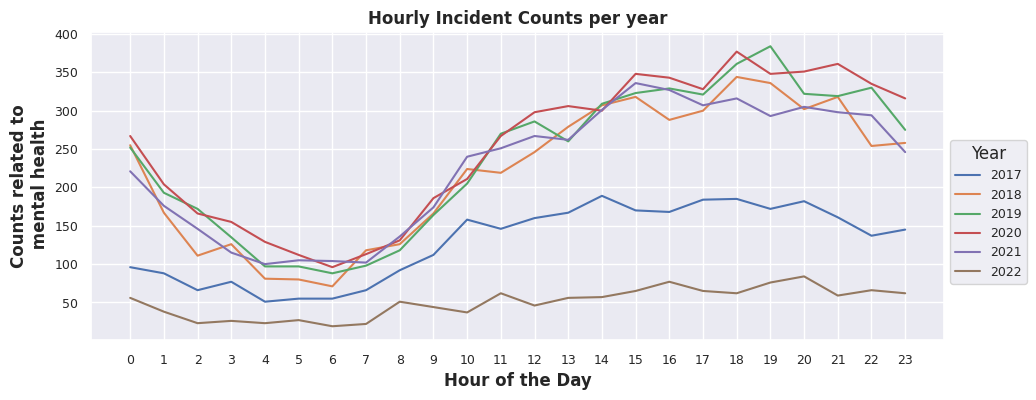

In [38]:
hourly_counts_by_year = df.groupby([df['incident_start_date'].dt.year, df['incident_start_date'].dt.hour]).size()

fig, ax = plt.subplots()

for year in hourly_counts_by_year.index.levels[0]:
    hourly_counts_by_year[year].plot(ax=ax, label=str(year))

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.legend(title='Year',prop=tickfont_properties, bbox_to_anchor=(1, 0.67))
plt.xlabel('Hour of the Day',**font_properties)
plt.xticks(**tickfont_properties)
plt.yticks(**tickfont_properties)
plt.ylabel('Counts related to\n mental health',**font_properties)
plt.title('Hourly Incident Counts per year',**font_properties)

Text(0.5, 1.0, 'Monthly Average Incident Counts per hour')

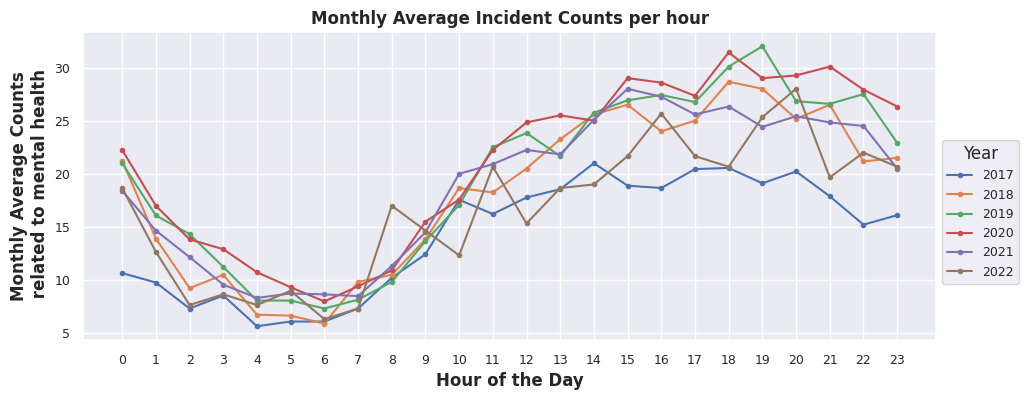

In [39]:
hourly_counts = df.groupby([df['incident_start_date'].dt.year, df['incident_start_date'].dt.hour]).size()
months_per_year = df.groupby(df['incident_start_date'].dt.year)['incident_start_month'].nunique()

mean_hourly_counts = hourly_counts / hourly_counts.index.get_level_values(0).map(months_per_year)

fig, ax = plt.subplots()
mean_hourly_counts.unstack().transpose().plot(ax=ax,marker='.', linestyle='-')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.legend(title='Year',prop=tickfont_properties, bbox_to_anchor=(1, 0.67))
plt.xlabel('Hour of the Day',**font_properties)
plt.xticks(**tickfont_properties)
plt.yticks(**tickfont_properties)
plt.ylabel('Monthly Average Counts\n related to mental health',**font_properties)
plt.title('Monthly Average Incident Counts per hour',**font_properties)

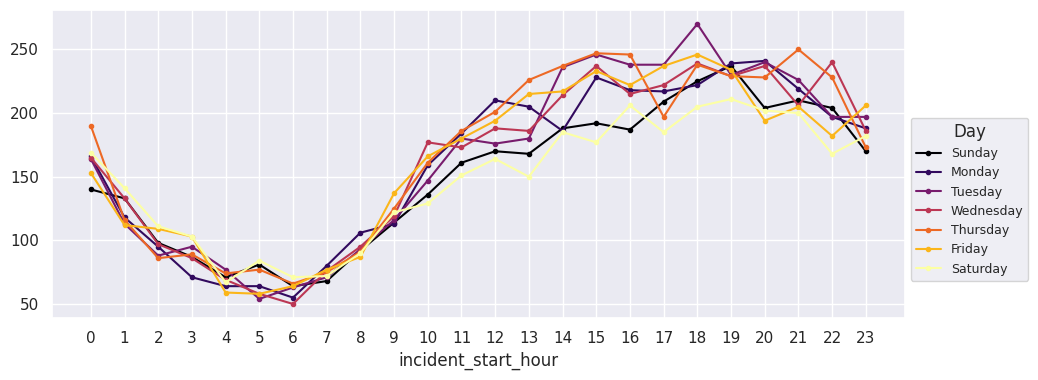

In [40]:
daily_seasonal = df[['incident_start_day','incident_start_hour']]
daily_seasonal = daily_seasonal.groupby(['incident_start_day','incident_start_hour']).size()
days = df['incident_start_day'].unique()
colors = plt.cm.inferno(np.linspace(0, 1, len(days)))
fig, ax = plt.subplots()
for i,day in enumerate(daily_seasonal.index.levels[0]):
    daily_seasonal[day].plot(ax=ax,color=colors[i],label=day,marker='.', linestyle='-')

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.legend(title='Day',prop=tickfont_properties, bbox_to_anchor=(1, 0.67))

In [41]:
daily_counts_crime_cat = df.groupby([df['incident_start_date'].dt.to_period('D'),'incident_type']).size()

crime_cat_daily = daily_counts_crime_cat.reset_index().set_index('incident_start_date').rename(columns={0:'Count'})
# count_crime_cat_wise = crime_cat_daily.groupby('incident_type').resample('W').mean()
# count_crime_cat_wise.unstack(level=0)['Count'].plot(subplots=True, layout=(16, 5), figsize=(30, 20), title='Weekly Resampled Data')
# count_crime_cat_wise.unstack(level=0)['Count'].plot(figsize=(30, 20), title='Weekly Resampled Data')

/var/tmp/ipykernel_9560/3557977.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  daily_counts_crime_cat = df.groupby([df['incident_start_date'].dt.to_period('D'),'incident_type']).size()


/var/tmp/ipykernel_9560/1048651058.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_yticklabels([tick.get_text() for tick in axes[i].get_yticklabels()], **tickfont_properties)
/var/tmp/ipykernel_9560/1048651058.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_yticklabels([tick.get_text() for tick in axes[i].get_yticklabels()], **tickfont_properties)
/var/tmp/ipykernel_9560/1048651058.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_yticklabels([tick.get_text() for tick in axes[i].get_yticklabels()], **tickfont_properties)
/var/tmp/ipykernel_9560/1048651058.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_yticklabels([tick.get_text() for tick in axes[i].get_yticklabels()], **tickfont_properties)
/var/tmp/ipykernel_9560/1048651058.py:15: UserWarning: FixedFormatter should only be used together with Fixe

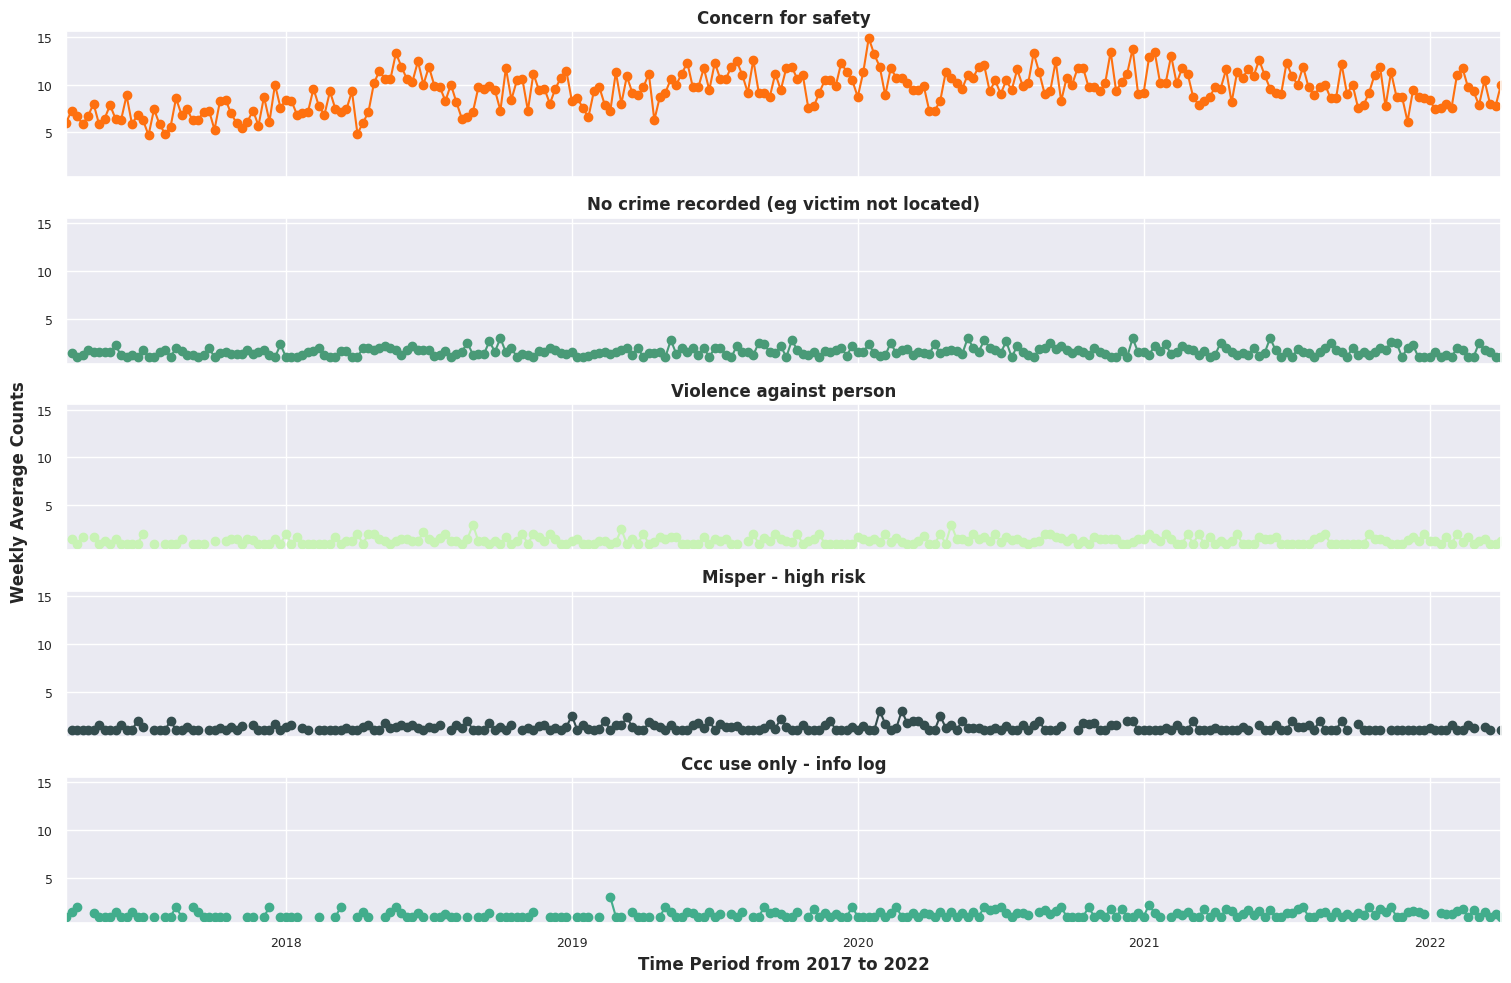

In [42]:
valid_crime_cat = crime_cat_daily.groupby('incident_type')['Count'].sum().sort_values(ascending=False).head(20)
valid_crime_cat = valid_crime_cat[valid_crime_cat>200].index[:5]
count_crime_cat_wise = crime_cat_daily[crime_cat_daily['incident_type'].isin(valid_crime_cat)].groupby('incident_type').resample('W').mean()
# count_crime_cat_wise.sort_values(by='Count',ascending=False,inplace=True)
# count_crime_cat_wise.unstack(level=0)['Count'].plot(subplots=True, layout=(10, 2), figsize=(30, 30), title='Weekly Resampled Data')

fig, axes = plt.subplots(len(valid_crime_cat), 1, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
color_type = generate_colors(len(valid_crime_cat))

for i, incident_type in enumerate(valid_crime_cat):
    data = count_crime_cat_wise.loc[incident_type]
    data['Count'].plot(ax=axes[i], title=incident_type,color=color_type[i],marker='o')
    axes[i].set_title(incident_type.capitalize(), **font_properties)
    axes[i].set_xticklabels([tick.get_text() for tick in axes[i].get_xticklabels()], **tickfont_properties)
    axes[i].set_yticklabels([tick.get_text() for tick in axes[i].get_yticklabels()], **tickfont_properties)

plt.xlabel('Time Period from 2017 to 2022',**font_properties)
fig.text(0, 0.5, 'Weekly Average Counts', ha='center', va='center', rotation='vertical',**font_properties)
plt.tight_layout()

/var/tmp/ipykernel_9560/2153100889.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], **tickfont_properties)


Text(0.5, 0, 'Time Period from 2017 to 2022')

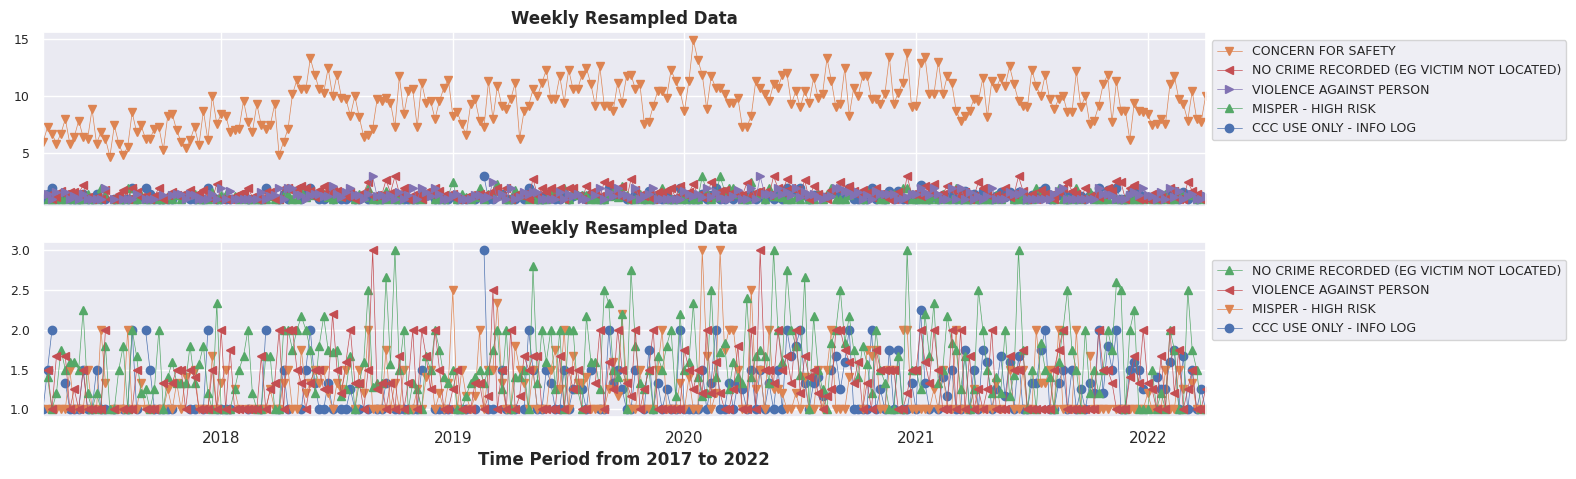

In [43]:
count_crime_cat = count_crime_cat_wise.unstack(level=0)['Count']
count_crime_cat_filt = count_crime_cat.loc[:, ~count_crime_cat.columns.isin(['CONCERN FOR SAFETY'])]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
count_crime_cat.plot(ax=ax1,figsize=(15, 5), title='Weekly Resampled Data',linewidth=0.5)
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D']

for i, line in enumerate(ax1.get_lines()):
    line.set_marker(markers[i % len(markers)])

handles, labels = ax1.get_legend_handles_labels()
label_totals = count_crime_cat.sum()
sorted_items = sorted(zip(handles, labels), key=lambda x: label_totals[x[1]], reverse=True)
sorted_handles, sorted_labels = zip(*sorted_items)

ax1.legend(sorted_handles, sorted_labels, loc='center left', bbox_to_anchor=(1, 0.67),prop=tickfont_properties)

count_crime_cat_filt.plot(ax=ax2,figsize=(15, 5), title='Weekly Resampled Data',linewidth=0.5)

for i, line in enumerate(ax2.get_lines()):
    line.set_marker(markers[i % len(markers)])
handles1, labels1 = ax2.get_legend_handles_labels()
label_totals1 = count_crime_cat_filt.sum()
sorted_items1 = sorted(zip(handles1, labels1), key=lambda x: label_totals1[x[1]], reverse=True)
sorted_handles1, sorted_labels1 = zip(*sorted_items1)

ax2.legend(sorted_handles1, sorted_labels1, loc='center left', bbox_to_anchor=(1, 0.67),prop=tickfont_properties)

for ax in (ax1, ax2):
    ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], **tickfont_properties)
    
ax1.set_title('Weekly Resampled Data',**font_properties)
ax2.set_title('Weekly Resampled Data',**font_properties)
plt.xlabel('Time Period from 2017 to 2022',**font_properties)

/var/tmp/ipykernel_9560/2807542750.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], **tickfont_properties)


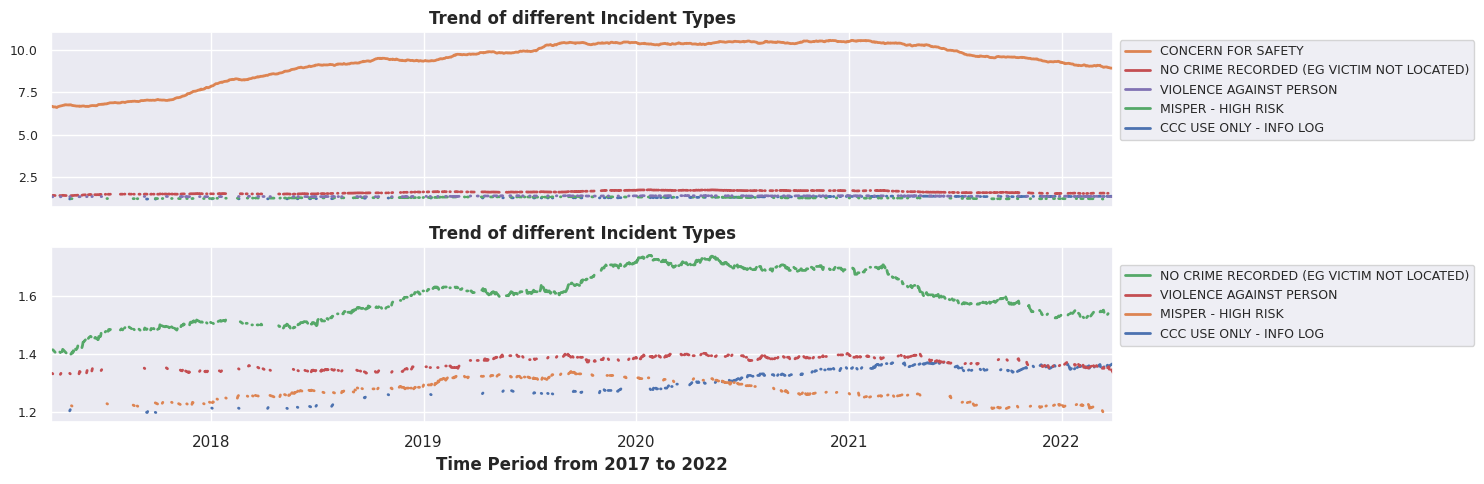

In [44]:
trend_crime_cat_wise = crime_cat_daily[crime_cat_daily['incident_type'].isin(valid_crime_cat)].groupby('incident_type').rolling(365,center=True,min_periods=1).mean()

trend_crime_cat_wise_filt = trend_crime_cat_wise.unstack(level=0)['Count']
trend_crime_cat_wise_filt = trend_crime_cat_wise_filt.loc[:, ~trend_crime_cat_wise_filt.columns.isin(['CONCERN FOR SAFETY'])]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
trend_crime_cat_wise.unstack(level=0)['Count'].plot(ax=ax1,figsize=(15, 5), title='Trend of different Incident Types',linewidth=2)


handles, labels = ax1.get_legend_handles_labels()
label_totals = trend_crime_cat_wise.groupby('incident_type')['Count'].sum()
sorted_items = sorted(zip(handles, labels), key=lambda x: label_totals[x[1]], reverse=True)
sorted_handles, sorted_labels = zip(*sorted_items)

ax1.legend(sorted_handles, sorted_labels, loc='center left', bbox_to_anchor=(1, 0.67),prop=tickfont_properties)

trend_crime_cat_wise_filt.plot(ax=ax2,figsize=(15, 5), title='Trend of different Incident Types',linewidth=2)
handles1, labels1 = ax2.get_legend_handles_labels()
label_totals1 = trend_crime_cat_wise_filt.sum()
sorted_items1 = sorted(zip(handles1, labels1), key=lambda x: label_totals1[x[1]], reverse=True)
sorted_handles1, sorted_labels1 = zip(*sorted_items1)
ax2.legend(sorted_handles1, sorted_labels1, loc='center left', bbox_to_anchor=(1, 0.67),prop=tickfont_properties)
for ax in (ax1, ax2):
    ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], **tickfont_properties)
    
ax1.set_title('Trend of different Incident Types',**font_properties)
ax2.set_title('Trend of different Incident Types',**font_properties)
    
plt.xlabel('Time Period from 2017 to 2022',**font_properties)
plt.tight_layout()

In [64]:
# Crime Incidents identified by Dan and Amanda
OurCrimeIncidentsTypesList = ["VIOLENCE AGAINST PERSON", "PUBLIC ORDER", "PUBLIC ORDER - SERIOUS DISORDER",  "PUBLIC ORDER - BREACH OF ASBO",
                      "HARASSMENT", "WEAPON - USED OR INVOLVED", "PUBLIC ORDER RELATED", "FIREARMS", 
                      "THREATS TO KILL", "SEXUAL OFFENCE", "FORCED MARRIAGE", "HATE INCIDENT- CRIME", "BURGLARY - RESIDENTIAL", 
                          "BURGLARY - BUSINESS & COMMUNITY", "MODERN SLAVERY", "ROBBERY", "ROBBERY - BANKS, CIT ETC", "FOUND STOLEN VEHICLE", 
                          "THEFT OF A VEHICLE", "THEFT FROM A VEHICLE", "THEFT - OTHER / HANDLING", "THEFT - SHOPLIFTING", 
                           "THEFT - MAKE OFF WITHOUT PAYMENT", "THEFT - FROM PERSON", "FRAUD/FORGERY", "ACTION FRAUD", "BANKING PROTOCOL (FRAUD)", 
                            "DRUGS", "ABDUCTION", "KIDNAP", "BLACKMAIL / EXTORTION", "HOMICIDE", 
                           "NO CRIME RECORDED (EG VICTIM NOT LOCATED)", "OTHER NOTIFIABLE CRIME", "CRIMINAL DAMAGE", 
                           "ASSAULT - SERIOUS INJURY", "CRIMINAL DAMAGE (HATE)", "HATE CRIME RELATED", "VIOLENCE AGAINST PERSON (HATE)", 
                           "BANKING PROTOCOL (FRAUD)", "DOMESTIC (NON CRIME)", "FIREARMS (NON CRIME)", "FORCED MARRIAGE (NON CRIME)", 
                              "HATE INCIDENT- NON CRIME", "HONOUR BASED VIOLENCE (NON CRIME)", "SUSP CIRCS - INV VEHICLE", "SUSPICIOUS CIRCUMSTANCES"]

df[df.incident_type.isin(OurCrimeIncidentsTypesList)]

,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,...,incident_start_year,incident_start_month,incident_start_day_num,incident_start_day,incident_start_hour,incident_end_year,incident_end_month,incident_end_day_num,incident_end_day,incident_end_hour
0,Bradford 002G,None,E01010698,E01010698,WYP-20190307-0933,True,None,False,NICHE CREATE OCCURRENCE,461.0,...,2019,March,7,Thursday,14,2019.0,March,7.0,Thursday,17.0
1,Bradford 003B,None,E01010768,E01010768,WYP-20190415-0307,True,None,False,NO OCCURRENCE REQUIRED,498.0,...,2019,April,15,Monday,8,2019.0,April,15.0,Monday,9.0
2,Bradford 004E,None,E01010642,E01010642,WYP-20180902-1163,True,None,False,NICHE CREATE OCCURRENCE,480.0,...,2018,September,2,Sunday,14,2018.0,September,2.0,Sunday,15.0
3,Bradford 004H,None,E01010645,E01010645,WYP-20190902-1159,True,None,False,NICHE CREATE OCCURRENCE,460.0,...,2019,September,2,Monday,16,2019.0,September,2.0,Monday,17.0
4,Bradford 008G,None,E01010710,E01010710,WYP-20190515-1025,True,None,False,NICHE CREATE OCCURRENCE,461.0,...,2019,May,15,Wednesday,14,2019.0,May,15.0,Wednesday,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26688,NaN,NaN,NaN,E01033697,NaN,N,,NV,NO OCCURRENCE REQUIRED- NO APP HO QUALIFIER,NaN,...,2022,March,15,Tuesday,0,2022.0,March,15.0,Tuesday,5.0
26690,NaN,NaN,NaN,E01010699,NaN,N,,NV,NICHE CREATE OCCURRENCE- VULNERABLE ADULT- ASB...,NaN,...,2021,January,13,Wednesday,22,2021.0,January,14.0,Thursday,7.0
26700,NaN,NaN,NaN,Unknown,NaN,Y,PRIORITY,N,NO OCCURRENCE REQUIRED,NaN,...,2020,April,17,Friday,21,2020.0,April,17.0,Friday,21.0
26723,NaN,NaN,NaN,Unknown,NaN,Y,PRIORITY,N,NO OCCURRENCE REQUIRED,NaN,...,2021,June,3,Thursday,10,2021.0,June,3.0,Thursday,22.0


,lsoa_name1,Index,lsoa1,lsoa,incident_ref,reswodep,initial_grade,attended,incident_sub_type,disposition_1_code,...,incident_start_year,incident_start_month,incident_start_day_num,incident_start_day,incident_start_hour,incident_end_year,incident_end_month,incident_end_day_num,incident_end_day,incident_end_hour
46,Bradford 061E,None,E01010872,E01010872,WYP-20190509-0743,True,None,False,NO OCCURRENCE REQUIRED,498.0,...,2019,May,9,Thursday,12,2019.0,May,12.0,Sunday,9.0
47,Unknown,None,Unknown,None,WYP-20171010-1607,False,STANDARD,False,NO OCCURRENCE REQUIRED,498.0,...,2017,October,10,Tuesday,18,2017.0,October,14.0,Saturday,17.0
48,Unknown,None,Unknown,None,WYP-20200211-0754,False,STANDARD,False,None,665.0,...,2020,February,11,Tuesday,13,2020.0,February,15.0,Saturday,13.0
50,Bradford 001D,None,E01010692,E01010692,WYP-20170703-0484,False,STANDARD,False,None,665.0,...,2017,July,3,Monday,9,2017.0,July,4.0,Tuesday,17.0
51,Bradford 003B,None,E01010768,E01010768,WYP-20180629-1205,False,STANDARD,True,None,665.0,...,2018,June,29,Friday,14,2018.0,July,2.0,Monday,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26685,NaN,NaN,NaN,E01033697,NaN,N,,NV,HISTORIC - 16+ AT TIME OF OFFENCE- VULNERABLE ...,NaN,...,2021,May,11,Tuesday,17,2021.0,May,12.0,Wednesday,17.0
26703,NaN,NaN,NaN,Unknown,NaN,Y,EMERGENCY,N,,NaN,...,2021,May,28,Friday,9,2021.0,May,29.0,Saturday,12.0
26715,NaN,NaN,NaN,Unknown,NaN,N,,Y,,NaN,...,2021,October,12,Tuesday,20,2021.0,October,15.0,Friday,12.0
26724,NaN,NaN,NaN,Unknown,NaN,N,,Y,,NaN,...,2021,June,3,Thursday,22,2021.0,June,5.0,Saturday,9.0


## Spatial Exploratory Analysis

In [45]:
import geopandas as gpd

df_lsoa = gpd.read_file('LSOA.geojson')

In [83]:
# df_lsoa_11_21 = gpd.read_file('LSOA_11_21.geojson')
# df_lsoa_11_21[df_lsoa_11_21.LSOA11NM.str.contains("Bradford 044")]

In [46]:
df_lsoa_bradford = df_lsoa[df_lsoa.LSOA21NM.str.contains("Bradford")]

<Axes: >

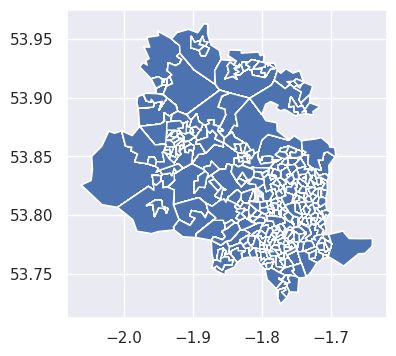

In [47]:
merged_df = pd.merge(df_lsoa_bradford, df, how='inner', left_on='LSOA21CD', right_on='lsoa')
merged_df.plot()

In [48]:
df_lsoa_bradford[~df_lsoa_bradford.LSOA21CD.isin(df.lsoa.unique())]

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
31939,31940,E01033898,Bradford 030E,,413001,435626,53.81677,-1.80402,9a1c0b34-287a-4a28-a4cc-38a64753202b,"POLYGON ((-1.79854 53.81875, -1.80018 53.81499..."
31940,31941,E01033899,Bradford 030F,,412584,435115,53.81219,-1.81037,58f837cf-4a48-43cf-a65e-2f7a9b4d288d,"POLYGON ((-1.80697 53.81097, -1.81353 53.81138..."
31941,31942,E01033900,Bradford 044G,,414764,432614,53.78965,-1.77738,34661eac-d3b2-4bdd-8d72-f7e6f8ac24ac,"POLYGON ((-1.77469 53.78937, -1.78014 53.79091..."
31942,31943,E01033901,Bradford 044H,,414682,432527,53.78887,-1.77863,90fa63b8-e8d7-4e89-80b0-6946f5f45e45,"POLYGON ((-1.77469 53.78937, -1.77376 53.78708..."


In [49]:
df[~df.lsoa.isin(df_lsoa_bradford.LSOA21CD.unique())].lsoa_name.unique()

array([None, 'Bradford 030C', 'Bradford 044B',
       'East Riding of Yorkshire 005A', 'Kirklees 003D', 'Leeds 004D',
       'Leeds 009B', 'Hambleton 004C', 'Leeds 111B', 'Unknown'],
      dtype=object)


**Bradford 030C** divided to form two LSOAs **Bradford 030E** and **Bradford 030F** in 2021. **Bradford 044B** divided to form two LSOAs **Bradford 044G** and **Bradford 044H** in 2021.

In [50]:
print(f"Number of Rows omitted after merging the data with the LSOA boundaries: {len(df)-len(merged_df)}")
print(f'Number of Rows in the original dataframe where the LSOA is UNKNOWN: {len(df[df.lsoa=="Unknown"])}')

Number of Rows omitted after merging the data with the LSOA boundaries: 410
Number of Rows in the original dataframe where the LSOA is UNKNOWN: 99


In [51]:
merged_df.columns

Index(['FID', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT',
       'LONG', 'GlobalID', 'geometry', 'lsoa_name1', 'Index', 'lsoa1', 'lsoa',
       'incident_ref', 'reswodep', 'initial_grade', 'attended',
       'incident_sub_type', 'disposition_1_code', 'qualifiers', 'final_grade',
       'incident_end_date', 'cb_date_added', 'incident_type', 'lsoa_name',
       'incident_start_date', 'incident_id', 'incident_start_year',
       'incident_start_month', 'incident_start_day_num', 'incident_start_day',
       'incident_start_hour', 'incident_end_year', 'incident_end_month',
       'incident_end_day_num', 'incident_end_day', 'incident_end_hour'],
      dtype='object')

In [54]:
# Get unique LSOAs and years
all_lsoas = merged_df['LSOA21CD'].unique()
all_years = merged_df['incident_start_year'].unique()

# Create full index (Cartesian product)
full_index = pd.MultiIndex.from_product([all_lsoas, all_years], names=['LSOA21CD', 'incident_start_year'])

merged_df_grouped = merged_df.groupby(['LSOA21CD','incident_start_year']).size()
merged_df_grouped = merged_df_grouped.reindex(full_index, fill_value=0).reset_index(name='Incident_counts')

geo_gdf = merged_df[['LSOA21CD', 'geometry']].drop_duplicates(subset='LSOA21CD')
geo_gdf = gpd.GeoDataFrame(geo_gdf, geometry='geometry')
geo_gdf = geo_gdf.to_crs(epsg=4326)
geo_gdf = geo_gdf.to_json()

In [56]:
import plotly.graph_objs as go
import json

# min year in the dataset
start_year = 2017
years = sorted(merged_df_grouped['incident_start_year'].unique())
# your color-scale
scl = [[0.0, '#ffffff'],[0.2, '#b4a8ce'],[0.4, '#8573a9'],
       [0.6, '#7159a3'],[0.8, '#5732a1'],[1.0, '#2c0579']] # purples

data_slider = []
for year in years:
    df_segmented =  merged_df_grouped[(merged_df_grouped['incident_start_year']== year)]

    choropleth = go.Choropleth(
        geojson=json.loads(geo_gdf),
        featureidkey="properties.LSOA21CD",  
        locations=df_segmented['LSOA21CD'],
        z=df_segmented['Incident_counts'].astype(float),
        colorscale=scl,
        colorbar={'title': 'Incident Counts'},
        visible=(year == start_year)
    )

    data_slider.append(choropleth)

steps = []
for i, year in enumerate(years):
    step = dict(
        method='restyle',
        args=['visible', [i == j for j in range(len(data_slider))]],
        label=str(year)
    )
    steps.append(step)

sliders = [dict(active=0, pad={"t": 1}, x=0.1, xanchor="left",steps=steps)]

layout = dict(
    title='Incident counts related to\n Mental Health Since 2017',
    width=1200,           
    height=700,
    margin=dict(t=0, b=0, l=0, r=0),
    geo=dict(
        projection=dict(
        type='mercator'),
        fitbounds="locations",
        showframe=False,
        showcoastlines=False,
        showland=True,
        landcolor='white',
        bgcolor='rgba(0,0,0,0)',
    ),
    sliders=sliders
)

fig = go.Figure(data=data_slider, layout=layout)
fig.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [ ]:
ts_daily_counts = df.groupby(df['incident_start_date'].dt.floor('D')).size()
ts_daily_counts = ts_daily_counts.asfreq('D')
add_decomp = seasonal_decompose(x=ts_daily_counts, model='multiplicative', period=365)

In [ ]:
# Utility function to make the plots
def seas_decomp_plots(original, decomposition):
    _, axes = plt.subplots(4, 1, sharex=True, sharey=False, figsize=(7, 5))
    axes[0].plot(original, label='Original')
    axes[0].legend(loc='upper left')
    axes[1].plot(decomposition.trend, label='Trend')
    axes[1].legend(loc='upper left')
    axes[2].plot(decomposition.seasonal, label='Seasonality')
    axes[2].legend(loc='upper left')
    axes[3].plot(decomposition.resid, label='Residuals')
    axes[3].legend(loc='upper left')
    plt.show()
    
seas_decomp_plots(ts_daily_counts, add_decomp)

In [ ]:
ts_daily_counts = ts_daily_counts.reset_index().rename(columns={0:'Freq'})